In [1]:
import json
import os
import clip
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from collections import defaultdict
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from ollama import Client

from utils import dataset_utils
from datasets.mvtec_dataset import MVTecDataset
from moviad.utilities.configurations import TaskType, LabelName

In [2]:
client = Client(host="http://localhost:6000")
os.environ["CUDA_VISIBLE_DEVICES"] = ""
MODEL_NAME = "gemma3:12b"
categories = ["grid"]
dataset_path = "/mnt/disk1/borsattifr/datasets/mvtec"

## Create concept list

In [4]:
for category in categories:

    concepts = set()

    train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
    train_dataset.load_dataset()

    test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
    test_dataset.load_dataset()

    anomalous_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.ABNORMAL]
    print(f"Number of anomalous images: {len(anomalous_samples)}")

    normal_test_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.NORMAL]
    normal_samples = pd.concat([train_dataset.samples, normal_test_samples])
    print(f"Number of normal images: {len(normal_samples)}")

    for i in range(len(normal_samples)):
        sample = normal_samples.iloc[i]
        concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample, anomalous = False)
        concepts.update(c.lower() for c in concept_json)
        
    
    for i in range(len(anomalous_samples)):
        sample = anomalous_samples.iloc[i]
        concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample, anomalous = True)
        concepts.update(c.lower() for c in concept_json)

    concepts = list(concepts)
    
    with open(f"concept_lists/original/{category}_concepts.json", "w") as f:
        json.dump(concepts, f)

Number of anomalous images: 57
Number of normal images: 285



## Inspect list

In [7]:
def number_of_concepts(category):
    path = f"concept_lists/original/{category}_concepts.json"
    with open(path, "r") as f:
        concepts = json.load(f)
    print(f"Original number of concepts for {category}:", len(concepts))
    return concepts

In [8]:
original_hazelnut_concepts = number_of_concepts("hazelnut")
original_carpet_concepts = number_of_concepts("carpet")
original_screw_concepts = number_of_concepts("screw")
original_grid_concepts = number_of_concepts("grid")


Original number of concepts for hazelnut: 149
Original number of concepts for carpet: 161
Original number of concepts for screw: 229
Original number of concepts for grid: 223


### First step: query an LLM to aggregate logically similar concepts

In [9]:
def filter_concepts(concepts, category):

    message = "You are an industrial expert that is performing the task of visual anomaly detection."\
            f"Given the following list of visual concepts: {concepts}, related to images of a {category}, please group together those that refer to the same LITERAL meaning, i.e. if they share key words, spelling..."\
            "Ignore semantic relationships, focus only on literal wording and string similarity."\
            "Moreover, choose a representative attribute that best summarizes the group."\
            "I provide two examples: 1. 'Elliptical shape': ['ellipsoidal shape', 'ellipsoid shape', 'elliptical shape']"\
            "2. 'Smooth texture': ['natural texture, 'smooth texture', 'smooth surface texture', 'smooth appearance', 'organic texture', 'uniform texture', 'consistent texture']"\
            "DO NOT create groups that are too general, e.g. grouping together all colours or all textures. Representative concepts should still be able to clearly discriminate between normal and anomalous images."\
            "Return the output as a JSON dictionary where each key is the representative concept, and its value is the list of similar concepts grouped with it."\
            "In case of concepts that cannot be grouped with any other concept, the dictionary should have both as key and value the concept itself."\
            "Please, output ONLY the JSON dictionary."

    response = client.chat(model=MODEL_NAME, messages=[{"role": "user", "content": message}])

    try:
        concept_json = dataset_utils.extract_json(response["message"]["content"])
    except Exception as e:
        print(f"Error parsing response: {e}")
        concept_json = []
    
    print(f"Number of concepts extracted by the LLM for {category}:", len(concept_json))
    print(f"Extracted concepts for {category}:", concept_json.keys())

    with open(f"concept_lists/filtered/{category}_concepts.json", "w") as f:
        json.dump(concept_json, f)

In [10]:
filter_concepts(original_grid_concepts, "grid")

Number of concepts extracted by the LLM for grid: 142
Extracted concepts for grid: dict_keys(['geometric design', 'organized structure', 'consistent texture', 'metal inclusion', 'irregular outline', 'embedded material', 'irregular spacing', 'localized curvature', 'gray color', 'white deposit', 'regular grid', 'broken grid', 'material snag', 'sharp angle', 'irregular texture', 'raised area', 'rectangular elements', 'geometric misalignment', 'localized accumulation', 'transparent patch', 'distorted grid', 'angular distortion', 'deviation from linearity', 'thread interruption', 'discontinuous line', 'irregular blob', 'foreign material', 'fractured element', 'straight lines', 'exposed internal structure', 'linear arrangement', 'non-linear grid', 'missing segment', 'dark discoloration', 'discoloration', 'angular deviation', 'irregular alignment', 'regular pattern', 'curved section', 'color variation', 'segmentation fault', 'excess material', 'glue deposit', 'dark metallic appearance', 'line

### Second step: filter concept list

In [11]:
def load_concepts(category):
    with open(f"concept_lists/filtered/{category}_concepts.json", "r") as f:
        filtered_concepts = json.load(f)

    final_concepts = list(filtered_concepts.keys())

    return final_concepts

In [12]:
final_grid_concepts = load_concepts("grid")

In [13]:
#remove concepts with high cosine similarity
def compute_concept_similarity(model, concepts, threshold = 0.9):
    model.eval()
    model.to("cpu")
    with torch.no_grad():
        text_tokens = clip.tokenize(concepts).to("cpu")
        text_features = model.encode_text(text_tokens)
    
        #normalize features
        text_features /= text_features.norm(dim = -1, keepdim = True)

    #compute cosine similarity between pairs
    similarities = (text_features @ text_features.T).cpu().numpy()
    np.fill_diagonal(similarities, 0.0) #ignore self-similarity

    high_sim_counts = (similarities > threshold).sum(axis = 1)

    print("\nHigh similarity pairs (> 0.9):")
    for i in range(len(concepts)):
        for j in range(i + 1, len(concepts)):
            sim = similarities[i, j]
            if sim > threshold:
                print(f"{concepts[i]} ↔ {concepts[j]}: {sim:.4f}")

    #remove concepts with more than two high-similarity matches
    concepts_to_remove = set(np.array(concepts)[high_sim_counts >= 2])

    #for remaining pairs, remove one of each
    remaining_idx = [i for i, c in enumerate(concepts) if c not in concepts_to_remove]
    remaining_concepts = [concepts[i] for i in remaining_idx]
    remaining_similarities = similarities[np.ix_(remaining_idx, remaining_idx)]

    #track which indices to drop
    already_removed = set()
    for i in range(len(remaining_idx)):
        for j in range(i + 1, len(remaining_idx)):
            if remaining_similarities[i, j] > threshold:
                if remaining_concepts[i] not in already_removed and remaining_concepts[j] not in already_removed:
                    already_removed.add(remaining_concepts[i])
    
    all_removed = concepts_to_remove.union(already_removed)

    final_concepts = [c for c in remaining_concepts if c not in already_removed]
    print("Concepts removed:", all_removed)
    print("Number of concepts kept:", len(final_concepts))

    return final_concepts

In [14]:
model, preprocess = clip.load("ViT-B/32", jit = False)

final_grid_concepts = compute_concept_similarity(model, final_grid_concepts)


High similarity pairs (> 0.9):
geometric design ↔ geometric misalignment: 0.9312
geometric design ↔ geometric distortion: 0.9268
geometric design ↔ geometric shapes: 0.9536
geometric design ↔ consistent geometry: 0.9199
geometric design ↔ geometric shape: 0.9609
geometric design ↔ angled structure: 0.9014
geometric design ↔ geometric pattern: 0.9741
geometric design ↔ geometric arrangement: 0.9243
organized structure ↔ exposed internal structure: 0.9009
organized structure ↔ linear structure: 0.9067
organized structure ↔ rectilinear structure: 0.9155
organized structure ↔ exposed structure: 0.9199
organized structure ↔ angled structure: 0.9209
organized structure ↔ grid structure: 0.9277
consistent texture ↔ material snag: 0.9121
consistent texture ↔ irregular texture: 0.9385
consistent texture ↔ excess material: 0.9072
consistent texture ↔ consistent spacing: 0.9131
consistent texture ↔ rough texture: 0.9487
consistent texture ↔ linear texture: 0.9390
consistent texture ↔ consistent 

In [15]:
## remove concepts that have a high cosine similarity with the class ("anomalous") or the category
def compute_class_similarity(model, concepts, category, classes = ["anomalous", "normal"], threshold = 0.9):
    references = [category] + classes

    with torch.no_grad():
        ref_tokens = clip.tokenize(references).to("cpu")
        ref_features = model.encode_text(ref_tokens)
        ref_features = ref_features / ref_features.norm(dim = -1, keepdim = True)

        text_tokens = clip.tokenize(concepts).to("cpu")
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim = -1, keepdim = True)
    
    similarities = (text_features @ ref_features.T).cpu().numpy()

    concepts_to_remove = set()
    for i, concept in enumerate(concepts):
        for j, ref in enumerate(references):
            sim = similarities[i, j]
            if sim > threshold:
                concepts_to_remove.add(concept)
                print(f"{concept} — high similarity to '{ref}': {sim:.4f}")
                break  # No need to check other references if already removed
    
    final_concepts = [c for c in concepts if c not in concepts_to_remove]
    print("Number of concepts kept:", len(final_concepts))
    return final_concepts

In [17]:
final_grid_concepts = compute_class_similarity(model, final_grid_concepts, "grid")

Number of concepts kept: 36


In [18]:
with open(f"concept_lists/filtered/grid_concepts.json", "w") as f:
        json.dump(final_grid_concepts, f)


## Final Dataset creation

### 1st strategy: VLM prompting

In [21]:
def create_final_dataset(category, final_concepts):
    normal_images_concepts = []
    anomalous_images_concepts = []

    train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
    train_dataset.load_dataset()

    test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
    test_dataset.load_dataset()

    anomalous_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.ABNORMAL]
    print(f"Number of anomalous images: {len(anomalous_samples)}")

    normal_test_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.NORMAL]
    normal_samples = pd.concat([train_dataset.samples, normal_test_samples])
    print(f"Number of normal images: {len(normal_samples)}")

    for i in range(len(normal_samples)):
        sample = normal_samples.iloc[i]
        concept_vector = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_concepts, anomalous = False)
        normal_images_concepts.append(concept_vector)

    normal_concepts_df = pd.DataFrame(normal_images_concepts, columns = [f"{c}" for c in final_concepts])
    normal_samples = pd.concat([normal_samples.reset_index(drop=True), normal_concepts_df], axis = 1)
    print("End of normal images") 

    for i in range(len(anomalous_samples)):
        sample = anomalous_samples.iloc[i]
        concept_vector_anomalous = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_concepts, anomalous = True)
        anomalous_images_concepts.append(concept_vector_anomalous)

    anomalous_concepts_df = pd.DataFrame(anomalous_images_concepts, columns = [f"{c}" for c in final_concepts])
    anomalous_samples = pd.concat([anomalous_samples.reset_index(drop=True), anomalous_concepts_df], axis = 1)
    print("End of anomalous images") 

    final_df = pd.concat([normal_samples, anomalous_samples], ignore_index = True)

    final_df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/{category}_dataset_automated.csv", index = False)

In [22]:
create_final_dataset("grid", final_grid_concepts)

Number of anomalous images: 57
Number of normal images: 285
End of normal images
End of anomalous images


### 2nd Strategy: CLIP

In [ ]:
model, preprocess = clip.load("ViT-B/32", jit = False)

In [32]:
### function to use CLIP on an image
def extract_concepts_with_clip(model, preprocess, df, concepts, category, threshold = 0.2):
    model.eval()
    model.to("cpu")
    text_inputs = torch.cat([clip.tokenize(f"a {category} with a {c}") for c in concepts]).to("cpu")

    concept_rows = []

    for i, row in df.iterrows():
        image_path = row["image_path"]
        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to("cpu")
        #calculate features
        with torch.no_grad():
            image_features = model.encode_image(image_input)
            text_features = model.encode_text(text_inputs)
    
        #normalize features
        image_features /= image_features.norm(dim = -1, keepdim = True)
        text_features /= text_features.norm(dim = -1, keepdim = True)

        #compute similarity between image and text features
        similarities = (100.0 * image_features @ text_features.T).softmax(dim = -1)
        probabilities = similarities[0].tolist()

        concept_presence = {concept: int(prob > threshold) for concept, prob in zip(concepts, probabilities)}
        concept_rows.append(concept_presence)
    
    concept_df = pd.DataFrame(concept_rows)
    
    for col in concept_df.columns:
        df[col] = concept_df[col]
    
    df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/{category}_dataset_clip.csv", index = False)

In [ ]:
path_hazelnut = "/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset.csv"
hazelnut_df = read_csv(path_hazelnut)

anomaly_concepts_obj = ["Crack", "Hole", "Split", "Fracture", "Visible Mark", "Visible Crevices", "Dark Interior", "Broken Shell", "Visible Ink"]
normal_concepts_obj = ["Intact Shell"]
anomaly_concepts_subj = ["Surface Imperfection", "Texture Anomaly", "Structural Damage", "Irregular Shape", "Surface Discontinuity", "Linear Disruption", "Irregular Edge", "Surface Disruption", "Localized Damage", "Uneven Tone", "Color Deviation"]
normal_concepts_subj = ["Compact Appearance", "Natural Appearance", "Uniform Appearance"]
uniformative_concepts = ["Color Contrast", "Visible Veins", "Irregular Edge", "Light Streaks", "Ovoid Shape", "Spherical Shape"]

valid_concepts = [c for c in final_hazelnut_concepts if c in anomaly_concepts_obj or c in normal_concepts_obj or c in normal_concepts_subj]
concepts = [c for c in valid_concepts if c in hazelnut_df.columns]

extract_concepts_with_clip(model, preprocess, hazelnut_df, concepts, category = "hazelnut")


### Split the dataset

In [ ]:
def read_csv(path):
    final_df = pd.read_csv(path)
    return final_df

In [83]:
def adjust_columns(df):
    #define the anomaly type
    if "label" in df.columns:
        df = df.rename(columns={"label": "anomaly_type"})

    #drop unnecessary columns
    if "split" in df.columns and "path" in df.columns:
        df = df.drop(columns = ["path", "split"])

    return df

In [84]:
carpet_df = adjust_columns(carpet_df)

In [39]:
def split_dataframe(df, train_size = 0.85, test_size = 0.5):   
    train_df, val_test_df = train_test_split(df, train_size = train_size, stratify=df["anomaly_type"], shuffle = True)

    val_df, test_df = train_test_split(val_test_df, test_size=test_size, shuffle = True)

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

    summary = df.groupby(["anomaly_type", "split"]).size().unstack(fill_value=0)
    print(summary)

    return df

In [40]:
carpet_df_automated = split_dataframe(carpet_df_automated)

split                test  train  val
anomaly_type                         
color                   1     16    2
cut                     1     14    2
good                   25    262   21
hole                    0     15    2
metal_contamination     2     14    1
thread                  1     16    2


In [42]:
carpet_df_automated.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset_automated.csv")

### Remove uninformative concepts

In [85]:
carpet_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")

In [86]:
def drop_concepts(df, concepts, num_images):
    existing_concepts = [col for col in concepts if col in df.columns]
    #drop concepts that appear in less than 10 images
    invalid_concepts = df[existing_concepts].sum()[lambda x: x < 10].index
    print("Concepts that appear in less than 10 images:", invalid_concepts)

    df = df.drop(columns=invalid_concepts)

    remaining_concepts = [col for col in existing_concepts if col not in invalid_concepts]
    #drop concepts that appear in more than 95% of the images
    always_present_concepts = df[remaining_concepts].sum()[lambda x: x > num_images * 0.95].index
    print("Concepts that appear in more than 95% of images:", always_present_concepts)

    df = df.drop(columns=always_present_concepts)

    remained_concepts = [col for col in concepts if col in df.columns]

    return df, remained_concepts

In [87]:
carpet_df, remained_carpet_concepts = drop_concepts(carpet_df, final_carpet_concepts, num_images=len(carpet_df))

Concepts that appear in less than 10 images: Index(['Exposed Backing', 'Looped Pile', 'Reddish Hue'], dtype='object')
Concepts that appear in more than 95% of images: Index(['Woven Pattern', 'Interwoven Structure', 'Fiber Strands',
       'Visible Fibers', 'Fibrous Appearance'],
      dtype='object')


### Remove highly correlated concepts

In [88]:
def compute_correlation(df, concepts, threshold = 0.9):
    concepts_to_use = [col for col in concepts if col in df.columns]
    correlation_matrix = df[concepts_to_use].corr().abs()

    plt.figure(figsize=(18, 15))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
    plt.show()

    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] >= threshold)]

    print(f"Concepts with correlation >= {threshold}: {to_drop}")

    df = df.drop(columns = to_drop)

    return df

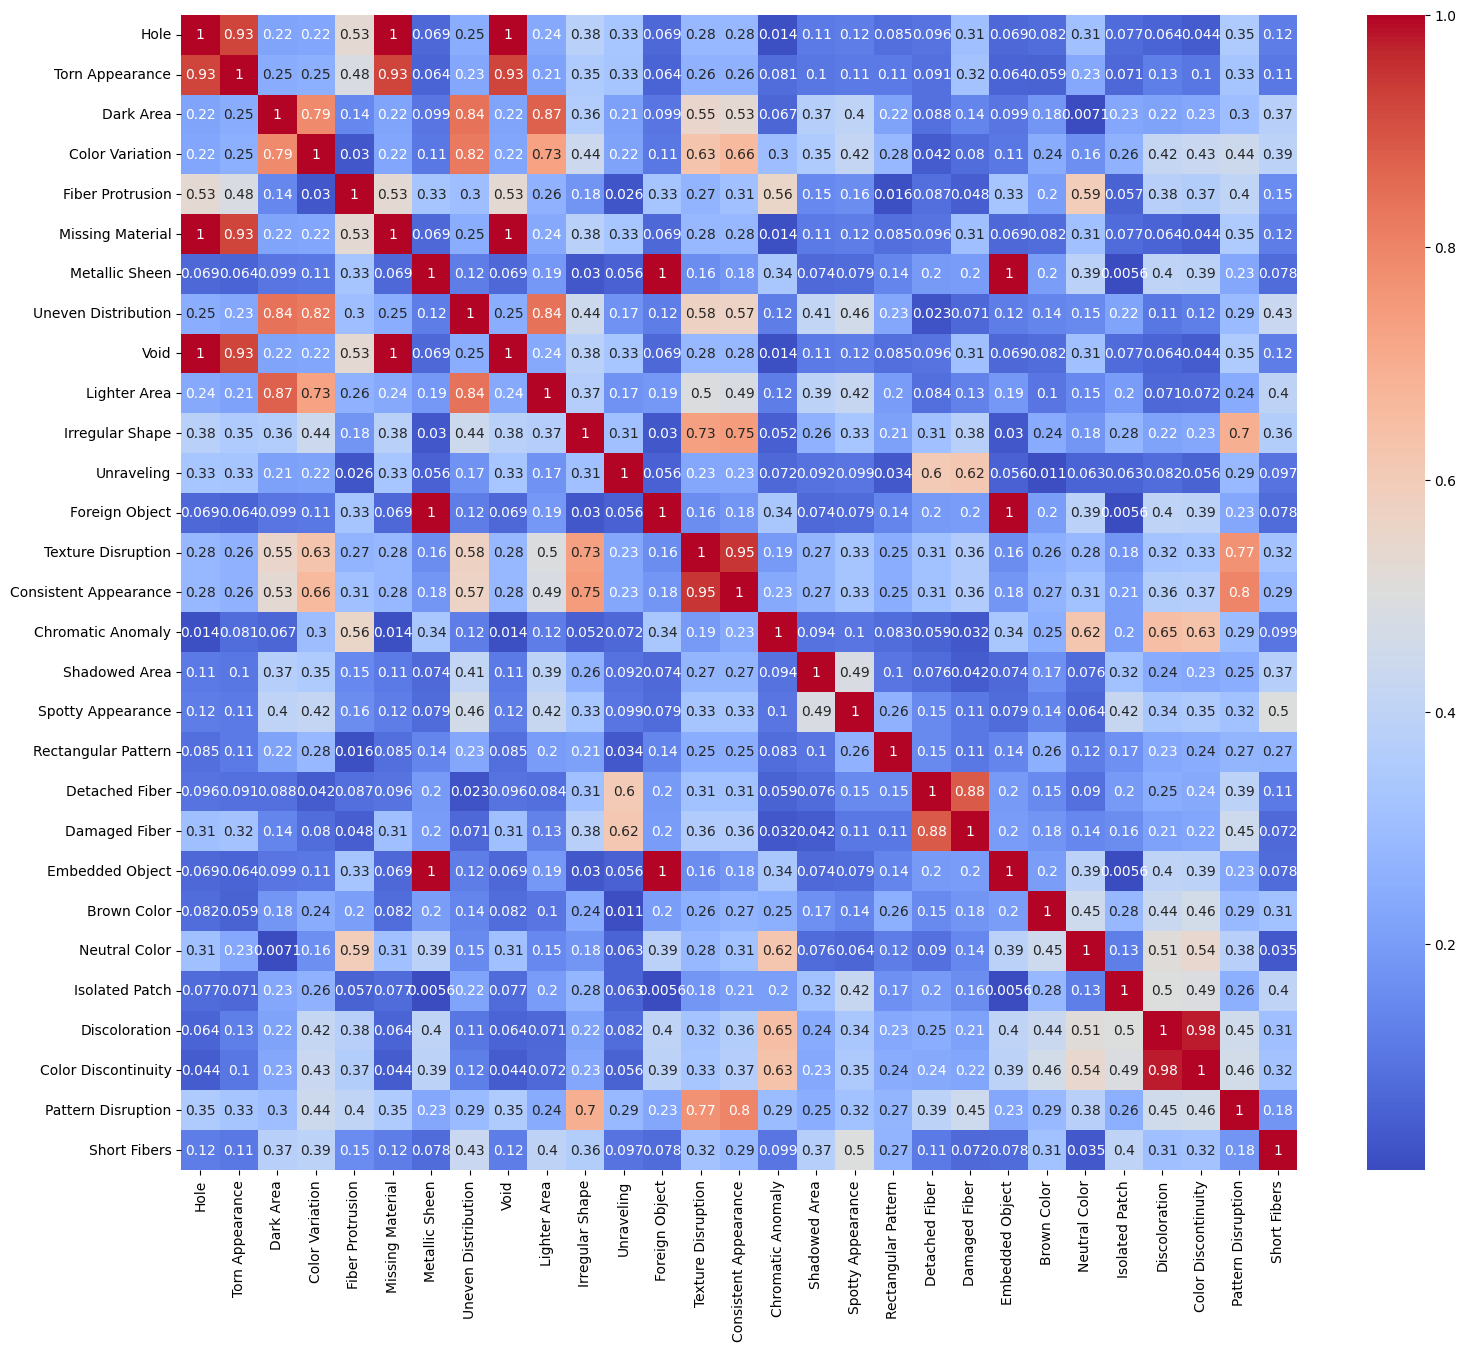

Concepts with correlation >= 0.9: ['Torn Appearance', 'Missing Material', 'Void', 'Foreign Object', 'Consistent Appearance', 'Embedded Object', 'Color Discontinuity']


In [89]:
carpet_df = compute_correlation(carpet_df, remained_carpet_concepts)

In [99]:
carpet_df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")
final_carpet_concepts = [col for col in final_carpet_concepts if col in carpet_df.columns]
print("Number of final concepts:", len(final_carpet_concepts))

Number of final concepts: 21


## (Optional) Manually check concept annotation

In [100]:
final_carpet_concepts

['Hole',
 'Dark Area',
 'Color Variation',
 'Fiber Protrusion',
 'Metallic Sheen',
 'Uneven Distribution',
 'Lighter Area',
 'Irregular Shape',
 'Unraveling',
 'Texture Disruption',
 'Chromatic Anomaly',
 'Shadowed Area',
 'Spotty Appearance',
 'Rectangular Pattern',
 'Detached Fiber',
 'Damaged Fiber',
 'Neutral Color',
 'Isolated Patch',
 'Discoloration',
 'Pattern Disruption',
 'Short Fibers']

In [106]:
#automatically exclude anomalous concepts
anomalous_concepts = ['Dark Area', 'Uneven Distribution', 'Color Variation', 'Fiber Protrusion', 'Hole', 'Metallic Sheen', 'Unraveling', 'Texture Disruption', 'Chromatic Anomaly', 'Pattern Disruption', 'Detached Fiber', 'Damaged Fiber']

carpet_df.loc[carpet_df["label_index"] == 0, anomalous_concepts] = 0

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image as PILImage
import ipywidgets as widgets
import os


# --- Define editable features ---
editable_columns = [col for col in carpet_df.columns if col not in ["image_path", "split", "label", "mask_path", "path"]]


def show_image(index):
    print(f"Rendering index {index}")
    row = carpet_df.iloc[index]

    img = PILImage.open(row["image_path"])
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {row['label_index']}")
    plt.show()

    # Create input widgets for each editable feature
    editors = {}
    for col in editable_columns:
        value = row[col]
        if isinstance(value, (int, float)):
            editor = widgets.FloatText(value=value, description=col)
        else:
            editor = widgets.Text(value=str(value), description=col)
        editors[col] = editor

    # Button to save edits
    save_button = widgets.Button(description="Save Changes", button_style='success')

    def save_changes(b):
        for col, widget in editors.items():
            carpet_df.at[index, col] = widget.value
        print(f"✅ Changes saved for index {index}")

    save_button.on_click(save_changes)

    # Display form
    display(widgets.VBox(list(editors.values()) + [save_button]))


# Interface to scroll through samples
widgets.interact(show_image, index=widgets.IntSlider(min=0, max=len(carpet_df)-1, step=1))

interactive(children=(IntSlider(value=0, description='index', max=396), Output()), _dom_classes=('widget-inter…

<function __main__.show_image(index)>

In [109]:
carpet_df.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv", index = False)

## (Done) Create complete dataset

In [ ]:
categories = ["bottle", "cable", "capsule", "carpet", "grid", "hazelnut", "leather", "metal_nut", "pill", "screw", "tile", "toothbrush", "transistor", "wood", "zipper"]
full_dataset = pd.DataFrame()

for category in categories:
    for split in ["train", "test"]:
        partial_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = split)
        partial_dataset.load_dataset()
        partial_dataset.samples["category"] = category

        full_dataset = pd.concat([full_dataset, partial_dataset.samples], ignore_index=True)

full_dataset = full_dataset.reset_index(drop=True)

In [12]:
full_dataset

,path,image_path,label_index,category,mask_path,stratify_key
0,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
1,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
2,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
3,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
4,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
...,...,...,...,...,...,...
5349,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1
5350,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1
5351,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1
5352,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1


In [10]:
full_dataset["stratify_key"] = full_dataset["category"].astype(str) + "_" + full_dataset["label_index"].astype(str)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_test_df = train_test_split(full_dataset, test_size=0.1, stratify=full_dataset["stratify_key"], shuffle = True)

val_df, test_df = train_test_split(val_test_df, test_size=0.5, stratify = val_test_df["stratify_key"], shuffle = True)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

full_dataset = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

In [28]:
full_dataset 

,image_path,label_index,category,mask_path,split
0,/mnt/disk1/borsattifr/datasets/mvtec/cable/tes...,0,cable,,train
1,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,train
2,/mnt/disk1/borsattifr/datasets/mvtec/capsule/t...,0,capsule,NaN,train
3,/mnt/disk1/borsattifr/datasets/mvtec/transisto...,0,transistor,NaN,train
4,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,carpet,NaN,train
...,...,...,...,...,...
5349,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,carpet,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,test
5350,/mnt/disk1/borsattifr/datasets/mvtec/pill/test...,1,pill,/mnt/disk1/borsattifr/datasets/mvtec/pill/grou...,test
5351,/mnt/disk1/borsattifr/datasets/mvtec/bottle/te...,1,bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/gr...,test
5352,/mnt/disk1/borsattifr/datasets/mvtec/pill/trai...,0,pill,NaN,test


In [29]:
full_dataset.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/full_dataset.csv", index = False)

## Analysis of concepts

### Discriminative analysis


In [110]:
cropped_carpet_df = carpet_df.iloc[:60]

In [111]:
#chi square test
def chi_square_test(df, concepts):
    for col in concepts:
        contingency = pd.crosstab(df[col], df["label_index"])
        chi2, p, dof, ex = chi2_contingency(contingency)
        print(f"{col}: p-value = {p:.2e}")
        prob_anomalous = df[df["label_index"] == 1][col].mean()
        prob_normal = df[df["label_index"] == 0][col].mean()
        print(f"{col}: P(concept=1 | anomaly) = {prob_anomalous:.2f}, P(concept=1 | normal) = {prob_normal:.2f}")

In [113]:
chi_square_test(cropped_carpet_df, final_carpet_concepts)

Hole: p-value = 4.08e-16
Hole: P(concept=1 | anomaly) = 0.38, P(concept=1 | normal) = 0.00
Dark Area: p-value = 9.80e-15
Dark Area: P(concept=1 | anomaly) = 0.25, P(concept=1 | normal) = 0.00
Color Variation: p-value = 4.08e-16
Color Variation: P(concept=1 | anomaly) = 0.38, P(concept=1 | normal) = 0.00
Fiber Protrusion: p-value = 2.12e-18
Fiber Protrusion: P(concept=1 | anomaly) = 0.56, P(concept=1 | normal) = 0.00
Metallic Sheen: p-value = 1.87e-13
Metallic Sheen: P(concept=1 | anomaly) = 0.12, P(concept=1 | normal) = 0.00
Uneven Distribution: p-value = 5.54e-21
Uneven Distribution: P(concept=1 | anomaly) = 0.75, P(concept=1 | normal) = 0.00
Lighter Area: p-value = 7.55e-13
Lighter Area: P(concept=1 | anomaly) = 0.06, P(concept=1 | normal) = 0.00
Irregular Shape: p-value = 2.12e-18
Irregular Shape: P(concept=1 | anomaly) = 0.56, P(concept=1 | normal) = 0.00
Unraveling: p-value = 4.08e-16
Unraveling: P(concept=1 | anomaly) = 0.38, P(concept=1 | normal) = 0.00
Texture Disruption: p-val

### Check differences between fully automated dataset and partially automated dataset

In [95]:
hazelnut_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset.csv")
hazelnut_df_automated = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_automated.csv")
hazelnut_df_clip = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_clip.csv")

In [50]:
final_hazelnut_concepts = [col for col in hazelnut_df.columns if col not in ["split", "anomaly_type", "image_path", "label_index", "mask_path"]]

In [57]:
carpet_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")
carpet_df_automated = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset_automated.csv")

In [61]:
cropped_carpet_df = carpet_df.iloc[:60]
cropped_carpet_df_automated = carpet_df_automated[carpet_df_automated["image_path"].isin(cropped_carpet_df["image_path"])]

In [68]:
final_carpet_concepts = [col for col in cropped_carpet_df.columns if col  not in ["Unnamed: 0", "split", "anomaly_type", "image_path", "label_index", "mask_path"]]

In [96]:
indexed_manual = hazelnut_df.set_index("image_path")
indexed_automated = hazelnut_df_automated.set_index("image_path")
indexed_clip = hazelnut_df_clip.set_index("image_path")

In [25]:
def check_differences(df_1, df_2, column_name):
    merged_df = df_1[[column_name]].rename(columns={column_name: f"manual_{column_name}"}).join(df_2[[column_name]].rename(columns={column_name: f"automated_{column_name}"}), how = "inner")
    merged_df["differences"] = merged_df[f"manual_{column_name}"] != merged_df[f"automated_{column_name}"]

    #compute accuracy 
    accuracy = (merged_df[f'manual_{column_name}'] == merged_df[f"automated_{column_name}"]).mean()

    #compute precision and recall
    TP = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    TN = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 0)).sum()
    FP = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    FN = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 0)).sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    # print(f"Accuracy of automated concepts for concept {column_name}: {accuracy:.2f}")
    # print(f"Precision of automated concepts for concept {column_name}: {precision:.2f}")
    # print(f"Recall of automated concepts for concept {column_name}: {recall:.2f}")

    return accuracy, precision, recall

In [26]:
def compute_avg_metrics(concepts, df_1, df_2, concept_type):
    all_acc = []
    all_prec = []
    all_rec = []

    for concept in concepts:
        accuracy, precision, recall = check_differences(df_1, df_2, concept)
        all_acc.append(accuracy)
        all_prec.append(precision)
        all_rec.append(recall)

    avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
    avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
    avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

    print(f"Average accuracy of {concept_type} concepts: {avg_acc:.2f} ± {std_acc:.2f}")
    print(f"Average precision of {concept_type} concepts: {avg_prec:.2f} ± {std_prec:.2f}")
    print(f"Average recall of {concept_type} concepts: {avg_rec:.2f} ± {std_rec:.2f}\n")

In [97]:
anomaly_concepts_obj = ["Crack", "Hole", "Split", "Fracture", "Visible Mark", "Visible Crevices", "Dark Interior", "Broken Shell", "Visible Ink"]
normal_concepts_obj = ["Intact Shell"]
anomaly_concepts_subj = ["Surface Imperfection", "Texture Anomaly", "Structural Damage", "Irregular Shape", "Surface Discontinuity", "Linear Disruption", "Uneven Tone", "Color Deviation"]
normal_concepts_subj = ["Compact Appearance", "Natural Appearance", "Uniform Appearance"]

all_clip_concepts = anomaly_concepts_obj + normal_concepts_obj + normal_concepts_subj

In [ ]:
anomaly_concepts_obj = ["Hole", "Dark Area", "Metallic Sheen", "Lighter Area", "Shadowed Area", "Unraveling", "Chromatic Anomaly", "Isolated Patch"]
anomaly_concepts_subj = ["Color Variation", "Uneven Distribution", "Irregular Shape", "Spotty Appearance", "Discoloration", "Pattern Disruption"]
uniformative_concepts = ["Rectangular Pattern", "Neutral Color"]

In [98]:
#compute differences with gemma-annotated df
compute_avg_metrics(final_carpet_concepts, indexed_manual, indexed_automated, "all")
compute_avg_metrics(anomaly_concepts_obj, indexed_manual, indexed_automated, "objective anomaly-related")
#compute_avg_metrics(normal_concepts_obj, indexed_manual, indexed_automated, "objective normality-related")
compute_avg_metrics(anomaly_concepts_subj, indexed_manual, indexed_automated, "subjective anomaly-related")
#compute_avg_metrics(normal_concepts_subj, indexed_manual, indexed_automated, "subjective normality-related")

KeyError: "None of [Index(['Unnamed: 0.1'], dtype='object')] are in the [columns]"

In [69]:
#compute differences with clip-annotated df
compute_avg_metrics(all_clip_concepts, indexed_manual, indexed_clip, "all")
compute_avg_metrics(anomaly_concepts_obj, indexed_manual, indexed_clip, "objective anomaly-related")
compute_avg_metrics(normal_concepts_obj, indexed_manual, indexed_clip, "objective normality-related")
compute_avg_metrics(normal_concepts_subj, indexed_manual, indexed_clip, "subjective normality-related")

Average accuracy of all concepts: 0.69 ± 0.34
Average precision of all concepts: 0.27 ± 0.40
Average recall of all concepts: 0.12 ± 0.18

Average accuracy of objective anomaly-related concepts: 0.90 ± 0.09
Average precision of objective anomaly-related concepts: 0.18 ± 0.32
Average recall of objective anomaly-related concepts: 0.13 ± 0.18

Average accuracy of objective normality-related concepts: 0.15 ± 0.00
Average precision of objective normality-related concepts: 0.00 ± 0.00
Average recall of objective normality-related concepts: 0.00 ± 0.00

Average accuracy of subjective normality-related concepts: 0.22 ± 0.18
Average precision of subjective normality-related concepts: 0.64 ± 0.45
Average recall of subjective normality-related concepts: 0.14 ± 0.19

